In [94]:
import os

paths = {
    "Train": os.path.join("dataset", "Train", "Train"),
    "Val": os.path.join("dataset", "Val", "Val"),
    "Test": os.path.join("dataset", "Test", "Test")
}

for folder, path in paths.items():

    print(f"\n===== {folder} =====")

    if os.path.exists(path):

        for class_name in os.listdir(path):

            class_path = os.path.join(path, class_name)

            if os.path.isdir(class_path):

                count = len([
                    f for f in os.listdir(class_path)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))
                ])

                print(f"{class_name}: {count}")

    else:
        print(f"{folder} folder not found!")


===== Train =====
Earthquake: 1927
Fire: 3509
Flood: 4063
Normal: 3900

===== Val =====
Earthquake: 239
Fire: 439
Flood: 505
Normal: 487

===== Test =====
Earthquake: 239
Fire: 436
Flood: 502
Normal: 477


In [95]:
print(train_data.class_names)

['Earthquake', 'Fire', 'Flood', 'Normal']


In [97]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/Train/Train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/Val/Val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/Test/Test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Train classes:", train_data.class_names)
print("Val classes:", val_data.class_names)
print("Test classes:", test_data.class_names)

Found 13399 files belonging to 4 classes.
Found 1670 files belonging to 4 classes.
Found 1654 files belonging to 4 classes.
Train classes: ['Earthquake', 'Fire', 'Flood', 'Normal']
Val classes: ['Earthquake', 'Fire', 'Flood', 'Normal']
Test classes: ['Earthquake', 'Fire', 'Flood', 'Normal']


In [98]:
total_test_images = 0

for images, labels in test_data:
    total_test_images += images.shape[0]

print("Total test images:", total_test_images)

Total test images: 1654


In [99]:
print("Number of classes:", len(train_data.class_names))
print("Classes:", train_data.class_names)
print("Model output classes:", model.output_shape[-1])

Number of classes: 4
Classes: ['Earthquake', 'Fire', 'Flood', 'Normal']
Model output classes: 4


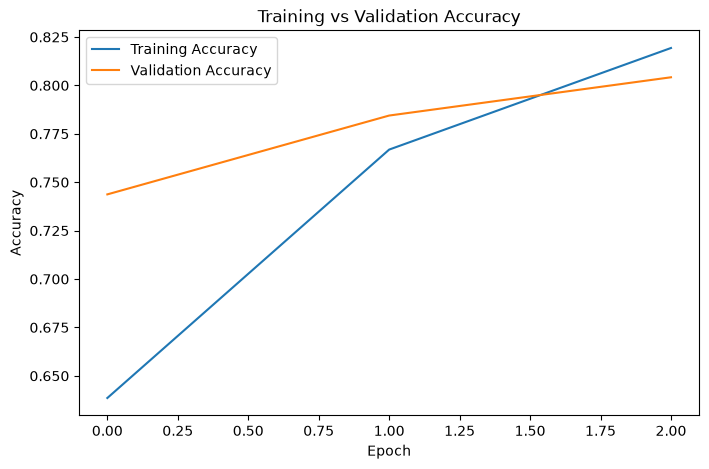

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

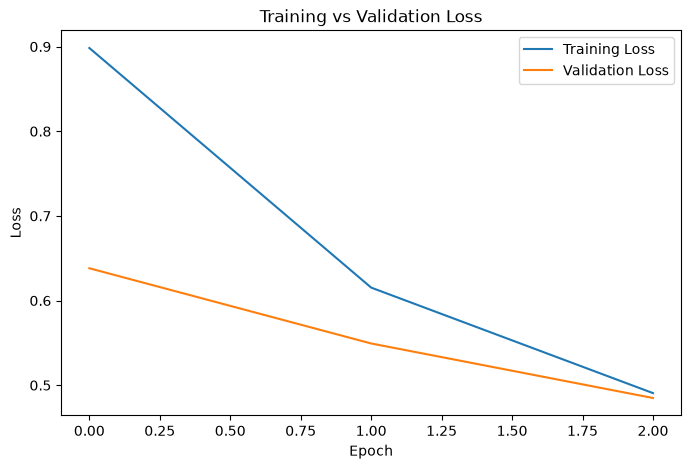

In [101]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [102]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.2074 - loss: 1.3897
Test Accuracy: 20.74%
Test Loss: 1.3897


In [103]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[158   2  78   1]
 [210   1 222   3]
 [321   2 174   5]
 [266   8 193  10]]


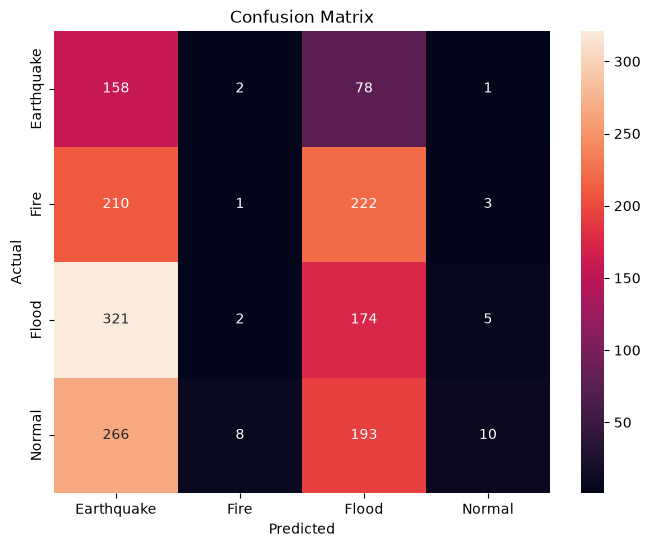

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=train_data.class_names,
    yticklabels=train_data.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [105]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

num_classes = len(train_data.class_names)

print("Classes:", train_data.class_names)
print("Number of classes:", num_classes)

# Pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# Improved model
improved_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),

    layers.Rescaling(1./127.5, offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

improved_model.summary()

Classes: ['Earthquake', 'Fire', 'Flood', 'Normal']
Number of classes: 4


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [106]:
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved model compiled successfully!")

Improved model compiled successfully!


In [108]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [109]:
history_improved = improved_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10


c:\Users\ANJU YADAV\Desktop\Disaster ditection & Alert System\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


419/419 ━━━━━━━━━━━━━━━━━━━━ 149s 342ms/step - accuracy: 0.8415 - loss: 0.4144 - val_accuracy: 0.8922 - val_loss: 0.2899 - learning_rate: 0.0010
Epoch 2/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 135s 323ms/step - accuracy: 0.8955 - loss: 0.2859 - val_accuracy: 0.8964 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 3/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 147s 350ms/step - accuracy: 0.9100 - loss: 0.2455 - val_accuracy: 0.8814 - val_loss: 0.3276 - learning_rate: 0.0010
Epoch 4/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 155s 370ms/step - accuracy: 0.9192 - loss: 0.2264 - val_accuracy: 0.8988 - val_loss: 0.2877 - learning_rate: 0.0010
Epoch 5/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 153s 364ms/step - accuracy: 0.9313 - loss: 0.1918 - val_accuracy: 0.9126 - val_loss: 0.2554 - learning_rate: 5.0000e-04
Epoch 6/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 145s 347ms/step - accuracy: 0.9378 - loss: 0.1759 - val_accuracy: 0.9156 - val_loss: 0.2428 - learning_rate: 5.0000e-04
Epoch 7/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 143s 342ms/step - accuracy:

In [110]:
test_loss_improved, test_accuracy_improved = improved_model.evaluate(test_data)

print(f"Improved Test Accuracy: {test_accuracy_improved * 100:.2f}%")
print(f"Improved Test Loss: {test_loss_improved:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.9365 - loss: 0.1794
Improved Test Accuracy: 93.65%
Improved Test Loss: 0.1794


In [111]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true_improved = []
y_pred_improved = []

for images, labels in test_data:
    predictions = improved_model.predict(images, verbose=0)

    y_true_improved.extend(labels.numpy())
    y_pred_improved.extend(np.argmax(predictions, axis=1))

y_true_improved = np.array(y_true_improved)
y_pred_improved = np.array(y_pred_improved)

cm_improved = confusion_matrix(
    y_true_improved,
    y_pred_improved
)

print("Improved Confusion Matrix:")
print(cm_improved)

Improved Confusion Matrix:
[[220   1  10   8]
 [  4 421   5   6]
 [  5   1 489   7]
 [ 14   8  36 419]]


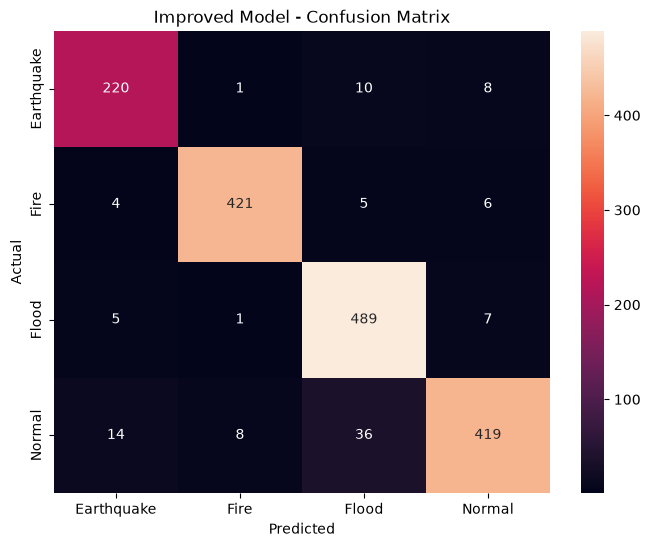

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_improved,
    annot=True,
    fmt='d',
    xticklabels=train_data.class_names,
    yticklabels=train_data.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Improved Model - Confusion Matrix")
plt.show()

In [113]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true_improved,
    y_pred_improved,
    target_names=train_data.class_names
)

print(report)

              precision    recall  f1-score   support

  Earthquake       0.91      0.92      0.91       239
        Fire       0.98      0.97      0.97       436
       Flood       0.91      0.97      0.94       502
      Normal       0.95      0.88      0.91       477

    accuracy                           0.94      1654
   macro avg       0.93      0.93      0.93      1654
weighted avg       0.94      0.94      0.94      1654



In [114]:
import os

os.makedirs("model", exist_ok=True)

improved_model.save("model/disaster_detection_model.keras")

print("Final model saved successfully!")

Final model saved successfully!


In [115]:
import os

print(os.path.exists("model/disaster_detection_model.keras"))

True


In [116]:
improved_model.save("model/disaster_detection_model.keras")

In [119]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Image path
image_path = r"dataset\Test\Test\Earthquake\image_0.png"

# Load image
img = load_img(image_path, target_size=(224, 224))

# Convert image to array
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = improved_model.predict(img_array, verbose=0)

# Get class and confidence
predicted_index = np.argmax(prediction[0])
predicted_class = train_data.class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Result
print("===================================")
print("      DISASTER DETECTION RESULT")
print("===================================")
print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence:.2f}%")

# Alert
if predicted_class != "Normal" and confidence >= 70:
    print("\n🚨 DISASTER ALERT!")
    print(f"⚠️ {predicted_class.upper()} DETECTED!")
    print("Immediate attention required.")

elif predicted_class == "Normal":
    print("\n✅ No disaster detected.")

else:
    print("\n⚠️ Low confidence prediction.")
    print("Please verify the image.")

      DISASTER DETECTION RESULT
Prediction : Earthquake
Confidence : 99.86%

🚨 DISASTER ALERT!
⚠️ EARTHQUAKE DETECTED!
Immediate attention required.


In [118]:
improved_model.save("model/disaster_detection_model.keras")